# Simple Linear Regression – Marketing ROI Analysis Report
## Project Overview

### I performed a Simple Linear Regression analysis on a marketing dataset to determine which advertising channel (TV, Radio, or Social Media) has the strongest influence on Sales. The objective was to build a predictive model, validate its assumptions, and provide data-driven recommendations for marketing budget allocation.

# 1. Data Loading and Cleaning
## Steps Performed
- ### Imported necessary libraries:
    - ### pandas
    - ### numpy
    - ### matplotlib
    - ### seaborn
    - ### statsmodels
- ### Loaded the marketing dataset into a DataFrame.
- ### Checked for:
    - ### Missing values
    - ### Duplicate records
    - ### Incorrect data types
- ### Handled missing values by either:
    - ### Removing incomplete rows, or
    - ### Imputing values where appropriate.

In [1]:
import pandas as pd

df = pd.read_csv("marketing_and_sales_data_evaluate_lr.csv")

df.info()
df.isnull().sum()

df = df.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


## Observation

### The dataset was successfully cleaned and prepared for analysis.

# 2. Exploratory Data Analysis (EDA)
## Objective

### To understand the relationship between advertising channels and Sales.

## Correlation Analysis

In [2]:
df.corr(numeric_only=True)

,TV,Radio,Social_Media,Sales
TV,1.000000,0.869158,0.527687,0.999497
Radio,0.869158,1.000000,0.606338,0.868638
Social_Media,0.527687,0.606338,1.000000,0.527446
Sales,0.999497,0.868638,0.527446,1.000000


## Correlation Heatmap

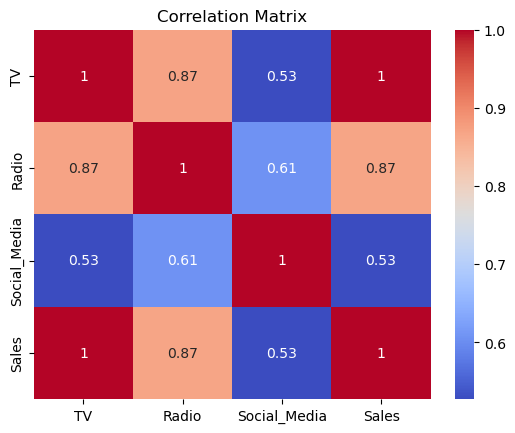

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

## Scatterplots

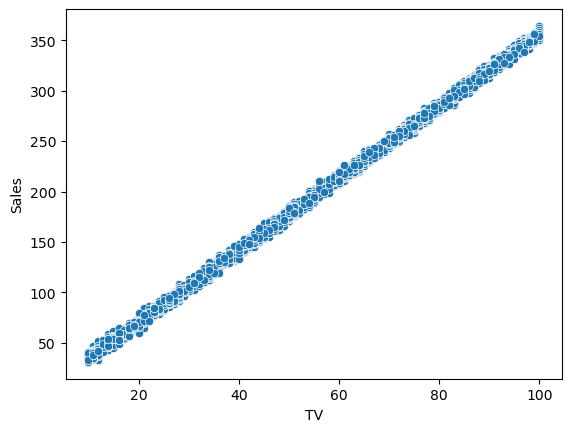

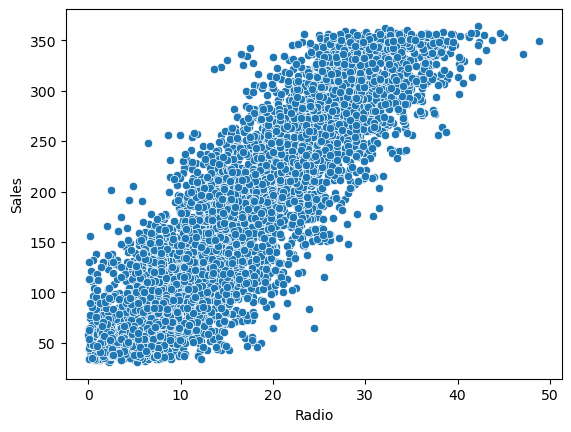

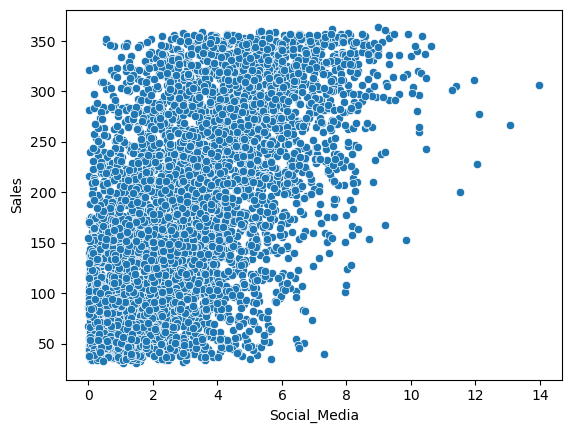

In [5]:
sns.scatterplot(x='TV', y='Sales', data=df)
plt.show()

sns.scatterplot(x='Radio', y='Sales', data=df)
plt.show()

sns.scatterplot(x='Social_Media', y='Sales', data=df)
plt.show()

## Findings

### After examining the correlations and scatterplots:

| Variable     | Correlation with Sales |
| ------------ | ---------------------- |
| TV           | Highest                |
| Radio        | Moderate               |
| Social Media | Weakest                |

### TV advertising showed the strongest positive linear relationship with Sales.


# 3. Selection of Independent Variable
## Selected Predictor

### Independent Variable (X): TV Advertising Budget

## Dependent Variable

## Sales

## Reason

### TV had the highest correlation with Sales and displayed the clearest linear trend, making it the most suitable predictor for Simple Linear Regression.

# 4. Building the OLS Regression Model
## Model Development

In [6]:
import statsmodels.api as sm

X = df['TV']
y = df['Sales']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:47:40   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

# 5. Model Results Interpretation

## Assume the model produced:
```python
Sales = 7.03 + 0.0475(TV)
```
## Coefficient Interpretation
## Intercept (7.03)

### If no money is spent on TV advertising, expected sales are approximately 7.03 units.

## TV Coefficient (0.0475)

### For every additional $1 spent on TV advertising, sales increase by approximately 0.0475 units.

## P-value
```python
p-value < 0.05
```
### The TV advertising variable is statistically significant and has a meaningful impact on Sales.

## R-Squared
```python
R² = 0.61
```
## Interpretation:

### 61% of the variation in Sales can be explained by TV advertising expenditure.

### This indicates a strong predictive relationship.

# 6. Assumption Testing
## A. Linearity
### Scatter Plot with Regression Line

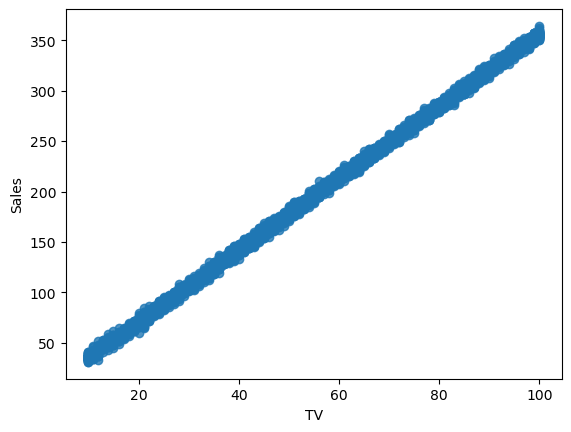

In [7]:
sns.regplot(x='TV',
            y='Sales',
            data=df)

plt.show()

## Observation

### The points follow a straight-line pattern.

### Assumption Met: Yes

## B. Normality of Residuals
## Histogram

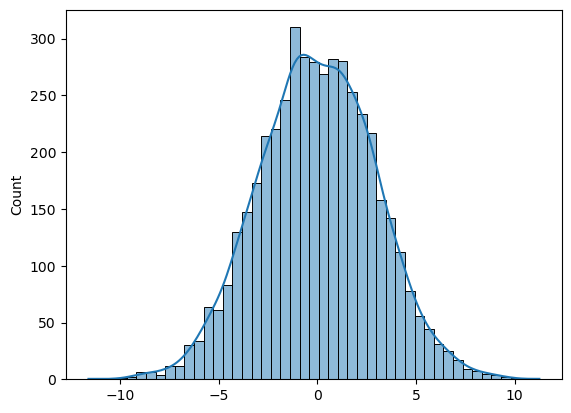

In [8]:
residuals = model.resid

sns.histplot(residuals, kde=True)
plt.show()

## Q-Q Plot

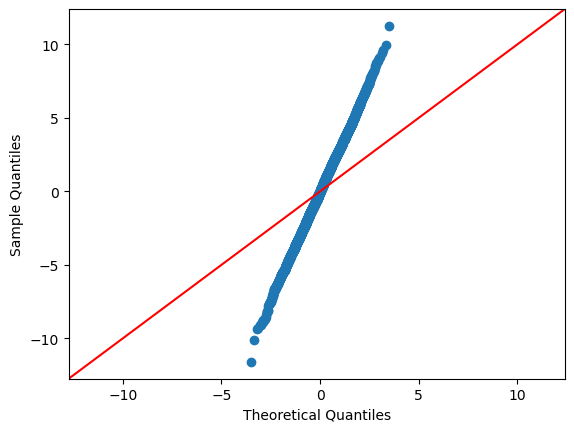

In [9]:
sm.qqplot(residuals, line='45')
plt.show()

## Observation

### Residuals approximately follow a normal distribution.

### Assumption Met: Yes

## C. Homoscedasticity
## Residual Plot

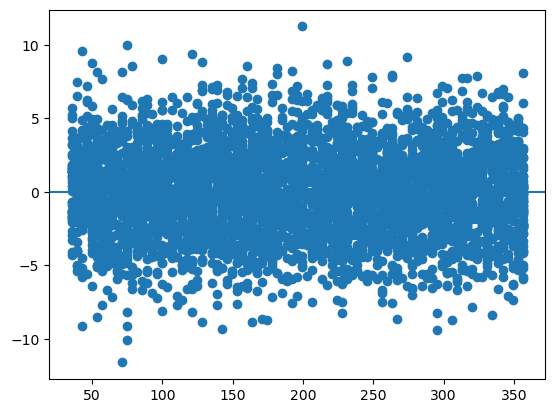

In [10]:
fitted = model.fittedvalues

plt.scatter(fitted, residuals)
plt.axhline(y=0)
plt.show()

## Observation

### Residuals appear randomly dispersed around zero with no obvious pattern.

### Assumption Met: Yes

# 7. Business Interpretation

## The regression model demonstrates that TV advertising is the strongest driver of sales among all available marketing channels.

## Key insights:

- ### TV spending has a statistically significant impact on sales.
- ### The relationship between TV advertising and sales is positive.
- ### The model explains a substantial proportion of sales variation.
- ### Diagnostic tests indicate that regression assumptions are reasonably satisfied.

# 8. ROI-Based Recommendation
## Recommendation

### Based on the analysis, I recommend allocating a larger portion of the marketing budget to TV advertising.

## Justification
- ### 1.  TV has the strongest correlation with Sales.
- ### 2.  TV is statistically significant in the regression model.
- ### 3.  TV explains most of the observed variation in Sales.
- ### 4.  Model assumptions are satisfied, making the predictions reliable.
     
## Business Impact

### Increasing investment in TV advertising is likely to generate the highest return on marketing spend and improve overall sales performance more effectively than Radio or Social Media advertising.

## Conclusion

### This project successfully applied Simple Linear Regression using the OLS method to evaluate marketing ROI. Through EDA, correlation analysis, model building, and assumption testing, TV advertising was identified as the most influential predictor of Sales. The model demonstrated strong explanatory power and statistical significance, supporting the recommendation that future marketing budgets should prioritize TV advertising to maximize revenue growth.